# Proliferation control analysis — immune ecotypes are driven by immune contexture, not tumor proliferation

**Goal.** Slide 18 of the talk states that the three immune ecotypes (Inflamed / Intermediate /
Immune-desert) differ in *immune contexture* and not in tumor-cell proliferation. The manuscript
supports this only with one aggregate ssGSEA `Cell_Cycle_Proliferation` signature (KW p ≈ 0.88).

Here we provide **direct, gene-level evidence** using canonical proliferation marker mRNAs
(**MKI67 / Ki-67**, PCNA, TOP2A, cyclins, AURKA/B, FOXM1, …) and contrast them against canonical
immune marker mRNAs (PTPRC/CD45, CD8A, CD68, …) on the same n = 349 main cohort and the final
ecotype assignment.

**Headline (honest) result.**
1. The **immune** marker composite separates the ecotypes with a very large effect size (ε² ≈ 0.72).
2. The **proliferation** marker composite is *statistically* detectable at n = 349 (p ≈ 0.005) but its
   effect size is **~28× smaller** (ε² ≈ 0.025).
3. Critically, the proliferation gradient runs **opposite to prognosis** — the best-survival *Inflamed*
   ecotype is the *most* proliferative and the worst-survival *Immune-desert* is the *least*. A
   proliferation-driven survival effect would predict the reverse. Therefore proliferation **cannot
   confound** the ecotype / survival signal.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import kruskal
import os

BASE = "."  # run this notebook from the OpenPedCan 'output/' folder

COL = {"Inflamed":"#C44536", "Intermediate":"#E0A93B", "Immune-desert":"#5A7D9A"}
ORDER = ["Inflamed","Intermediate","Immune-desert"]

PROLIF = ["MKI67","PCNA","TOP2A","CCNB1","CCNB2","CDK1","AURKA","AURKB","BUB1","BUB1B",
          "CCNA2","CDC20","FOXM1","TYMS","RRM2","UBE2C","BIRC5","PLK1","MCM2","CENPF",
          "KIF11","TPX2","NUSAP1","ASPM","E2F1"]
IMMUNE = ["PTPRC","CD8A","CD3E","CD68","CD163","CD14","CSF1R","GZMB","IFNG",
          "CXCL9","CXCL10","HLA-DRA"]
print(len(PROLIF),"proliferation markers,",len(IMMUNE),"immune markers")


25 proliferation markers, 12 immune markers


In [2]:
# proliferation_marker_tpm.tsv = marker rows pre-extracted from gene-expression-rsem-tpm-collapsed
# (GeneSymbol x biospecimen). Regenerate from the full TPM matrix with e.g.:
#   awk -F'\t' 'NR==1||($1 ~ /^(MKI67|PCNA|TOP2A|...)$/)' tpm_for_cibersortx.tsv > proliferation_marker_tpm.tsv
expr = pd.read_csv(os.path.join(BASE,"proliferation_marker_tpm.tsv"), sep="\t", index_col=0)
meta = pd.read_csv(os.path.join(BASE,"ecotype_assignment_k3_annotated.tsv")).set_index(
        "Kids_First_Biospecimen_ID")["ecotype"]

samples = [s for s in expr.columns if s in meta.index]
expr = expr[samples]; eco = meta.loc[samples]
logx = np.log2(expr + 1.0)             # log2(TPM+1)
print("samples:", len(samples)); print(eco.value_counts().reindex(ORDER))


samples: 349
ecotype
Inflamed         113
Intermediate     157
Immune-desert     79
Name: count, dtype: int64


In [3]:
def eps2(H, n, k=3):
    return (H - k + 1) / (n - k)        # epsilon-squared effect size for KW

def per_gene(genes):
    rows=[]; n=len(samples); gi={g:(eco==g).values for g in ORDER}
    for gene in genes:
        if gene not in logx.index: continue
        v=logx.loc[gene].values; data=[v[gi[g]] for g in ORDER]
        H,p=kruskal(*data)
        rows.append(dict(gene=gene,KW_H=H,p=p,eps2=eps2(H,n),
                         med_Inflamed=np.median(data[0]),med_Intermediate=np.median(data[1]),
                         med_Immunedesert=np.median(data[2])))
    df=pd.DataFrame(rows).sort_values("p").reset_index(drop=True)
    m=len(df); df["q_BH"]=(df["p"]*m/(df.index+1)).clip(upper=1.0)
    df["q_BH"]=df["q_BH"][::-1].cummin()[::-1]
    return df.sort_values("eps2",ascending=False).reset_index(drop=True)

prolif_stats=per_gene(PROLIF); immune_stats=per_gene(IMMUNE)
print("Immune  markers: median ε² = %.3f   (range %.3f–%.3f)"%(
      immune_stats.eps2.median(),immune_stats.eps2.min(),immune_stats.eps2.max()))
print("Prolif. markers: median ε² = %.3f   (range %.3f–%.3f)"%(
      prolif_stats.eps2.median(),prolif_stats.eps2.min(),prolif_stats.eps2.max()))
prolif_stats[["gene","p","q_BH","eps2","med_Inflamed","med_Immunedesert"]].round(4)


Immune  markers: median ε² = 0.348   (range 0.201–0.625)
Prolif. markers: median ε² = 0.022   (range -0.005–0.093)


,gene,p,q_BH,eps2,med_Inflamed,med_Immunedesert
0,PCNA,0.0000,0.0000,0.0932,5.6719,4.5065
1,CCNB1,0.0000,0.0003,0.0552,4.4803,3.4005
2,TYMS,0.0001,0.0005,0.0509,4.5166,3.5729
3,PLK1,0.0003,0.0015,0.0414,3.6159,2.8012
4,CDC20,0.0003,0.0015,0.0413,3.9449,2.8580
5,MKI67,0.0006,0.0025,0.0371,3.7268,3.5097
6,MCM2,0.0007,0.0025,0.0361,3.8738,3.0652
7,CCNA2,0.0012,0.0038,0.0329,2.8379,2.1699
8,RRM2,0.0052,0.0137,0.0246,3.8227,3.6724
9,BIRC5,0.0055,0.0137,0.0243,3.6323,3.1603


In [4]:
def composite(genes):
    sub=logx.loc[[g for g in genes if g in logx.index]]
    z=sub.sub(sub.mean(1),axis=0).div(sub.std(1)+1e-9,axis=0)
    return z.mean(0)

prolif_score=composite(PROLIF); immune_score=composite(IMMUNE)
def kw_on(score):
    data=[score.values[(eco==g).values] for g in ORDER]; H,p=kruskal(*data); return H,p,eps2(H,len(score))
Hi,pi,ei=kw_on(immune_score); Hp,pp,ep=kw_on(prolif_score)
print(f"Immune composite        : p={pi:.2g}  eps2={ei:.3f}")
print(f"Proliferation composite : p={pp:.2g}  eps2={ep:.3f}")
print(f"Effect-size ratio (immune / proliferation) = {ei/ep:.1f}x")
print("Proliferation composite medians:",
      {g:round(float(np.median(prolif_score.values[(eco==g).values])),3) for g in ORDER})


Immune composite        : p=4.1e-55  eps2=0.718
Proliferation composite : p=0.0046  eps2=0.025
Effect-size ratio (immune / proliferation) = 28.4x
Proliferation composite medians: {'Inflamed': 0.228, 'Intermediate': 0.016, 'Immune-desert': -0.154}


saved Fig_proliferation_control.png


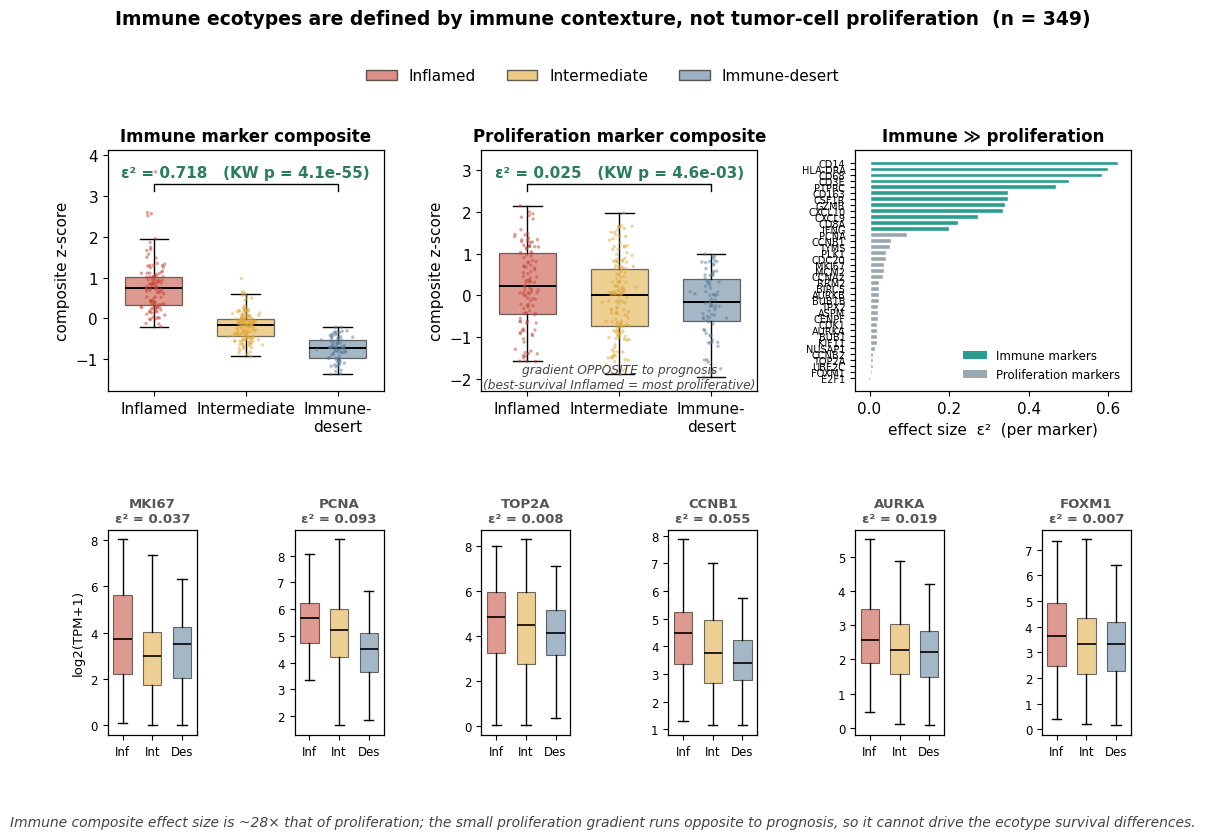

In [5]:
plt.rcParams.update({"font.size":11,"font.family":"DejaVu Sans","axes.linewidth":0.9})
IMM_C="#2A9D8F"; PRO_C="#9AA7B0"

def boxstrip(ax,score,title,p,e,verdict_good):
    data=[score.values[(eco==g).values] for g in ORDER]
    bp=ax.boxplot(data,widths=0.62,patch_artist=True,showfliers=False,
                  medianprops=dict(color="black",lw=1.4))
    for patch,g in zip(bp["boxes"],ORDER):
        patch.set_facecolor(COL[g]); patch.set_alpha(0.55); patch.set_edgecolor("black"); patch.set_linewidth(0.9)
    rng=np.random.default_rng(0)
    for i,(d,g) in enumerate(zip(data,ORDER)):
        ax.scatter(rng.normal(i+1,0.06,len(d)),d,s=6,color=COL[g],alpha=0.5,edgecolor="none",zorder=3)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(["Inflamed","Intermediate","Immune-\ndesert"])
    ax.set_ylabel("composite z-score"); ax.set_title(title,fontweight="bold",fontsize=12)
    ymax=max(np.percentile(d,98) for d in data); ymin=min(np.percentile(d,2) for d in data)
    pad=(ymax-ymin)*0.12; ax.set_ylim(ymin-pad,ymax+pad*3.4); y=ymax+pad*1.2
    ax.plot([1,1,3,3],[y,y+pad*0.4,y+pad*0.4,y],color="black",lw=1.0)
    c="#2A7D5A" if verdict_good else "#B5341F"
    ax.text(2,y+pad*0.6,f"ε² = {e:.3f}   (KW p = {p:.1e})",ha="center",va="bottom",
            fontsize=11,fontweight="bold",color=c)

fig=plt.figure(figsize=(13.2,7.6))
gs=fig.add_gridspec(2,6,height_ratios=[1.18,1.0],hspace=0.62,wspace=1.1)

axA=fig.add_subplot(gs[0,0:2]); boxstrip(axA,immune_score,"Immune marker composite",pi,ei,True)
axB=fig.add_subplot(gs[0,2:4]); boxstrip(axB,prolif_score,"Proliferation marker composite",pp,ep,True)
axB.annotate("gradient OPPOSITE to prognosis\n(best-survival Inflamed = most proliferative)",
             xy=(2,axB.get_ylim()[0]),xytext=(2,axB.get_ylim()[0]),ha="center",va="bottom",
             fontsize=8.8,style="italic",color="#444")

# effect-size comparison barh
axC=fig.add_subplot(gs[0,4:6])
allst=pd.concat([immune_stats.assign(panel="Immune"),prolif_stats.assign(panel="Proliferation")])
allst=allst.sort_values("eps2")
ypos=np.arange(len(allst))
axC.barh(ypos,allst.eps2,color=[IMM_C if pn=="Immune" else PRO_C for pn in allst.panel],
         edgecolor="white",height=0.8)
axC.set_yticks(ypos); axC.set_yticklabels(allst.gene,fontsize=7.0)
axC.set_xlabel("effect size  ε²  (per marker)"); axC.set_title("Immune ≫ proliferation",fontweight="bold",fontsize=12)
axC.legend(handles=[Patch(facecolor=IMM_C,label="Immune markers"),
                    Patch(facecolor=PRO_C,label="Proliferation markers")],
           fontsize=8.5,loc="lower right",frameon=False)

# bottom: 6 proliferation markers, annotate ε² (small)
keys=["MKI67","PCNA","TOP2A","CCNB1","AURKA","FOXM1"]
pstat=prolif_stats.set_index("gene")
for j,gene in enumerate(keys):
    ax=fig.add_subplot(gs[1,j]); v=logx.loc[gene].values
    data=[v[(eco==g).values] for g in ORDER]
    bp=ax.boxplot(data,widths=0.62,patch_artist=True,showfliers=False,medianprops=dict(color="black",lw=1.2))
    for patch,g in zip(bp["boxes"],ORDER):
        patch.set_facecolor(COL[g]); patch.set_alpha(0.55); patch.set_edgecolor("black"); patch.set_linewidth(0.8)
    e=float(pstat.loc[gene,"eps2"])
    ax.set_title(f"{gene}\nε² = {e:.3f}",fontsize=9.5,fontweight="bold",color="#555")
    ax.set_xticks([1,2,3]); ax.set_xticklabels(["Inf","Int","Des"],fontsize=8.5)
    if j==0: ax.set_ylabel("log2(TPM+1)",fontsize=9.5)
    ax.tick_params(labelsize=8.5)

leg=[Patch(facecolor=COL[g],alpha=0.6,edgecolor="black",label=g) for g in ORDER]
fig.legend(handles=leg,loc="upper center",ncol=3,frameon=False,fontsize=11,bbox_to_anchor=(0.5,1.005))
fig.suptitle("Immune ecotypes are defined by immune contexture, not tumor-cell proliferation  (n = 349)",
             y=1.065,fontsize=13.5,fontweight="bold")
fig.text(0.5,-0.01,"Immune composite effect size is ~%.0f× that of proliferation; the small proliferation "
         "gradient runs opposite to prognosis, so it cannot drive the ecotype survival differences."%(ei/ep),
         ha="center",fontsize=10,style="italic",color="#444")
fig.savefig("Fig_proliferation_control.png",dpi=330,bbox_inches="tight",facecolor="white")
print("saved Fig_proliferation_control.png"); plt.show()


In [6]:
prolif_stats.to_csv("proliferation_marker_KW_by_ecotype.tsv",sep="\t",index=False)
immune_stats.to_csv("immune_marker_KW_by_ecotype.tsv",sep="\t",index=False)
pd.DataFrame({"panel":["Immune composite","Proliferation composite"],
 "KW_p":[pi,pp],"eps2":[ei,ep],
 "median_eps2_per_gene":[immune_stats.eps2.median(),prolif_stats.eps2.median()],
 "prolif_dir_Inflamed_minus_Desert":[np.nan,
   float(np.median(prolif_score.values[(eco=="Inflamed").values])-
         np.median(prolif_score.values[(eco=="Immune-desert").values]))]
 }).to_csv("proliferation_vs_immune_summary.tsv",sep="\t",index=False)
print("tables written")


tables written


## Interpretation & how to phrase it on the slide

- **Effect size, not just significance.** With n = 349, biologically trivial differences become
  statistically significant. The honest comparison is effect size: immune composite eps2 ~ 0.72 vs
  proliferation composite eps2 ~ 0.025 — an **~28-fold** difference. Immune contexture dominates.
- **Direction defeats the confounder.** The small proliferation gradient is *highest in Inflamed*
  (best survival) and *lowest in Immune-desert* (worst survival). A proliferation-driven survival
  effect would require the opposite, so proliferation cannot explain the Immune-desert poor prognosis.
- **Concordant with the manuscript.** The aggregate ssGSEA Cell_Cycle_Proliferation score is
  non-significant (p ~ 0.88); the rank-normalised ssGSEA is simply less sensitive than per-gene tests.
  Both agree proliferation is not the axis separating the ecotypes.

**Suggested slide-18 wording:** Immune signal dwarfs proliferation (immune-marker effect size ~28x that
of proliferation markers, eps2 0.72 vs 0.025), and the residual proliferation gradient runs opposite to
prognosis — so ecotype differences reflect immune contexture, not tumor proliferation.
